# SHAP Analysis: Understanding XGBoost Fraud Detection

This notebook provides interactive SHAP (SHapley Additive exPlanations) analysis for our fraud detection models.

**Goals:**
1. Understand which features drive fraud predictions
2. Compare feature importance across model variants (baseline vs hybrid)
3. Investigate false positives and false negatives
4. Identify why GNN embeddings don't improve performance

**Prerequisites:**
- Run training with `--save-models` flag to generate model artifacts
- Example: `python -m src.cli train-baseline --save-models`

**Note:** If you encounter errors about corrupted model parameters, restart the Python kernel (Kernel → Restart Kernel) and run all cells again. The explainability module automatically fixes corrupted XGBoost models.


In [1]:
import sys
import os
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import SHAP
import shap

# Set working directory to project root (assuming notebook is in notebooks/ subdirectory)
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
    os.chdir(project_root)
else:
    project_root = Path.cwd()

# Add project root to path
sys.path.insert(0, str(project_root))

# Force reload the explainability module to get latest fixes
if 'src.utils.explainability' in sys.modules:
    importlib.reload(sys.modules['src.utils.explainability'])

from src.utils.explainability import (
    ModelExplainer, 
    load_saved_model, 
    compare_models,
    save_explainer
)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
shap.initjs()

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print(f"Project root: {project_root}")
print(f"Artifacts directory exists: {os.path.exists('artifacts')}")
print(f"✓ Module reloaded - using latest explainability fixes")


Project root: /Users/dylan/Repos/ppa-fraud-notebook
Artifacts directory exists: True
✓ Module reloaded - using latest explainability fixes


### Available Models

First, let's check what models are available for analysis.


In [2]:
# List all available model types
models_base = project_root / "artifacts" / "models"
if models_base.exists():
    print("Available model types:")
    print("="*60)
    for d in sorted(models_base.iterdir()):
        if d.is_dir():
            model_files = list(d.glob("model_window_*.pkl"))
            if model_files:
                # Get window indices
                window_indices = []
                for f in model_files:
                    try:
                        # Extract window index from filename
                        idx_str = f.stem.replace("model_window_", "")
                        window_indices.append(int(idx_str))
                    except:
                        pass
                window_indices = sorted(window_indices)
                print(f"\n{d.name}:")
                print(f"  Total models: {len(model_files)}")
                if window_indices:
                    print(f"  Window range: {min(window_indices)} to {max(window_indices)}")
                    print(f"  Latest window: {max(window_indices)}")
else:
    print("No models directory found. Run training first.")


Available model types:

baseline:
  Total models: 134
  Window range: 0 to 133
  Latest window: 133

baseline_graph:
  Total models: 134
  Window range: 0 to 133
  Latest window: 133

hybrid_gat:
  Total models: 67
  Window range: 0 to 66
  Latest window: 66

hybrid_hgt:
  Total models: 67
  Window range: 0 to 66
  Latest window: 66

hybrid_hgt_rte:
  Total models: 67
  Window range: 0 to 66
  Latest window: 66

hybrid_sage:
  Total models: 67
  Window range: 0 to 66
  Latest window: 66


## 1. Load Models

Load saved models from training runs. You can choose which model type and window to analyze.


In [3]:
# Configuration
MODEL_TYPE = "baseline"  # Options: baseline, baseline_graph, hybrid_hgt, hybrid_sage, hybrid_gat, hybrid_hgt_rte
WINDOW_IDX = -1  # -1 for latest, or specify window index

# Find available models - use absolute path from project root
models_dir = project_root / "artifacts" / "models" / MODEL_TYPE

if not models_dir.exists():
    print(f"⚠️ Models directory does not exist: {models_dir}")
    print(f"\nAvailable model directories:")
    models_base = project_root / "artifacts" / "models"
    if models_base.exists():
        for d in sorted(models_base.iterdir()):
            if d.is_dir():
                count = len(list(d.glob("model_window_*.pkl")))
                print(f"  {d.name}: {count} models")
    else:
        print(f"  No models directory found at {models_base}")
else:
    model_files = sorted(models_dir.glob("model_window_*.pkl"))
    model_files = [str(f) for f in model_files]  # Convert to strings
    
    print(f"Found {len(model_files)} model windows in {models_dir}")
    if model_files:
        print(f"\nLast 5 model files:")
        for i, f in enumerate(model_files[-5:]):  # Show last 5
            print(f"  {os.path.basename(f)}")
    else:
        print("\n⚠️ No model files found in directory!")
        print(f"Example: python -m src.cli train-baseline --save-models")


Found 134 model windows in /Users/dylan/Repos/ppa-fraud-notebook/artifacts/models/baseline

Last 5 model files:
  model_window_95.pkl
  model_window_96.pkl
  model_window_97.pkl
  model_window_98.pkl
  model_window_99.pkl


In [4]:
# Load the selected model
if not model_files:
    raise FileNotFoundError("No model files available. Please train models first.")

model_path = model_files[WINDOW_IDX]
print(f"Loading: {os.path.basename(model_path)}")
print(f"Full path: {model_path}")

model_bundle = load_saved_model(model_path)

# Display model info
print("\n" + "="*60)
print("Model Information")
print("="*60)
print(f"  Window: {model_bundle['window_info']['window_start']} to {model_bundle['window_info']['window_end']}")
print(f"  Window Index: {model_bundle['window_info'].get('window_idx', 'N/A')}")
print(f"  Train size: {model_bundle['window_info']['train_size']:,}")
print(f"  Test size: {model_bundle['window_info']['test_size']:,}")
print(f"  Features: {len(model_bundle['features'])}")
print(f"\nPerformance Metrics:")
for k, v in model_bundle['metrics'].items():
    if k != 'window_start':
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")

# Display sample feature names
print(f"\nSample features (first 10):")
for i, feat in enumerate(model_bundle['features'][:10]):
    print(f"  {i+1}. {feat}")
if len(model_bundle['features']) > 10:
    print(f"  ... and {len(model_bundle['features']) - 10} more")


Loading: model_window_99.pkl
Full path: /Users/dylan/Repos/ppa-fraud-notebook/artifacts/models/baseline/model_window_99.pkl

Model Information
  Window: 2025-02-22 07:36:27.382000+00:00 to 2025-03-08 07:36:27.382000+00:00
  Window Index: 99
  Train size: 21,514
  Test size: 3,976
  Features: 14

Performance Metrics:
  auc_pr: 0.5914
  auc_roc: 0.9136
  p@50: 0.7600
  r@50: 0.0854
  lift@50: 6.7905
  p@100: 0.7700
  r@100: 0.1730
  lift@100: 6.8798
  p@200: 0.6850
  r@200: 0.3079
  lift@200: 6.1204
  fraud_count: 445

Sample features (first 10):
  1. account_age_days
  2. log_price
  3. living_space
  4. rooms
  5. is_new
  6. has_balcony
  7. has_elevator
  8. has_parking
  9. bundle_period
  10. bundle_tier_score
  ... and 4 more


## 2. Create SHAP Explainer

Initialize the SHAP explainer and compute SHAP values for all test instances.


In [5]:
# Create explainer
print("Creating SHAP explainer (this may take a moment)...")
explainer = ModelExplainer(
    model=model_bundle['model'],
    feature_names=model_bundle['features'],
    X_test=model_bundle['X_test'],
    y_test=model_bundle['y_test'],
    y_pred=model_bundle['y_pred'],
    model_type=MODEL_TYPE,
    window_info=model_bundle['window_info']
)

print(f"\n✓ SHAP explainer created successfully!")
print(f"  SHAP values shape: {explainer.shap_values.shape}")
print(f"  Expected value (base): {explainer.expected_value:.4f}")

# Display test set statistics
print(f"\nTest Set Statistics:")
print(f"  Total instances: {len(explainer.y_test):,}")
print(f"  Fraud cases (y=1): {explainer.y_test.sum():,} ({explainer.y_test.mean()*100:.2f}%)")
print(f"  Legitimate cases (y=0): {(explainer.y_test == 0).sum():,} ({(1-explainer.y_test.mean())*100:.2f}%)")
print(f"  Mean predicted probability: {explainer.y_pred.mean():.4f}")
print(f"  Predicted fraud (>=0.5): {(explainer.y_pred >= 0.5).sum():,}")

# Show prediction type distribution
pred_counts = explainer.df_test['prediction_type'].value_counts()
print(f"\nPrediction Type Distribution:")
for pred_type in ['TP', 'TN', 'FP', 'FN']:
    count = pred_counts.get(pred_type, 0)
    if count > 0:
        print(f"  {pred_type}: {count:,}")


Creating SHAP explainer (this may take a moment)...
Checking model integrity and fixing if needed...
Note: Model normalized but TreeExplainer test failed: could not convert string to float: '[5E-1]'
Will use fallback SHAP explainer methods...
Initializing SHAP TreeExplainer...
Standard TreeExplainer failed: could not convert string to float: '[5E-1]'
Trying TreeExplainer with model_output='probability'...
TreeExplainer with probability output also failed: could not convert string to float: '[5E-1]'
Falling back to KernelExplainer (this will be slower)...
Computing SHAP values...


  0%|          | 0/3976 [00:00<?, ?it/s]

/Users/dylan/Repos/ppa-fraud-notebook/.venv/lib/python3.10/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/dylan/Repos/ppa-fraud-notebook/.venv/lib/python3.10/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/dylan/Repos/ppa-fraud-notebook/.venv/lib/python3.10/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)



✓ SHAP explainer created successfully!
  SHAP values shape: (3976, 14, 2)
  Expected value (base): 0.4369

Test Set Statistics:
  Total instances: 3,976
  Fraud cases (y=1): 445 (11.19%)
  Legitimate cases (y=0): 3,531 (88.81%)
  Mean predicted probability: 0.2275
  Predicted fraud (>=0.5): 800

Prediction Type Distribution:
  TP: 353
  TN: 3,084
  FP: 447
  FN: 92


### 2.1 Test Data Preview

Preview of the test data that will be analyzed.


In [6]:
# Display sample of test data
print("Sample Test Data:")
print("="*60)
sample_df = explainer.df_test[['y_true', 'y_pred', 'predicted_fraud', 'prediction_type']].head(10)
print(sample_df.to_string())

print(f"\n\nFull test data shape: {explainer.df_test.shape}")
print(f"Columns: {list(explainer.df_test.columns[:15])}..." if len(explainer.df_test.columns) > 15 else f"Columns: {list(explainer.df_test.columns)}")


Sample Test Data:
   y_true    y_pred  predicted_fraud prediction_type
0    True  0.935990                1              TP
1    True  0.933034                1              TP
2    True  0.910778                1              TP
3    True  0.894874                1              TP
4   False  0.001219                0              TN
5   False  0.002902                0              TN
6   False  0.815975                1              FP
7    True  0.894494                1              TP
8    True  0.902176                1              TP
9   False  0.280941                0              TN


Full test data shape: (3976, 18)
Columns: ['account_age_days', 'log_price', 'living_space', 'rooms', 'is_new', 'has_balcony', 'has_elevator', 'has_parking', 'bundle_period', 'bundle_tier_score', 'is_direct_payment', 'is_buy', 'latitude', 'longitude', 'y_true']...


## 3. Global Feature Importance

### 3.1 SHAP Summary Plot
Shows how each feature contributes to predictions across all instances.


Generating SHAP summary plot...


<Figure size 1200x800 with 0 Axes>

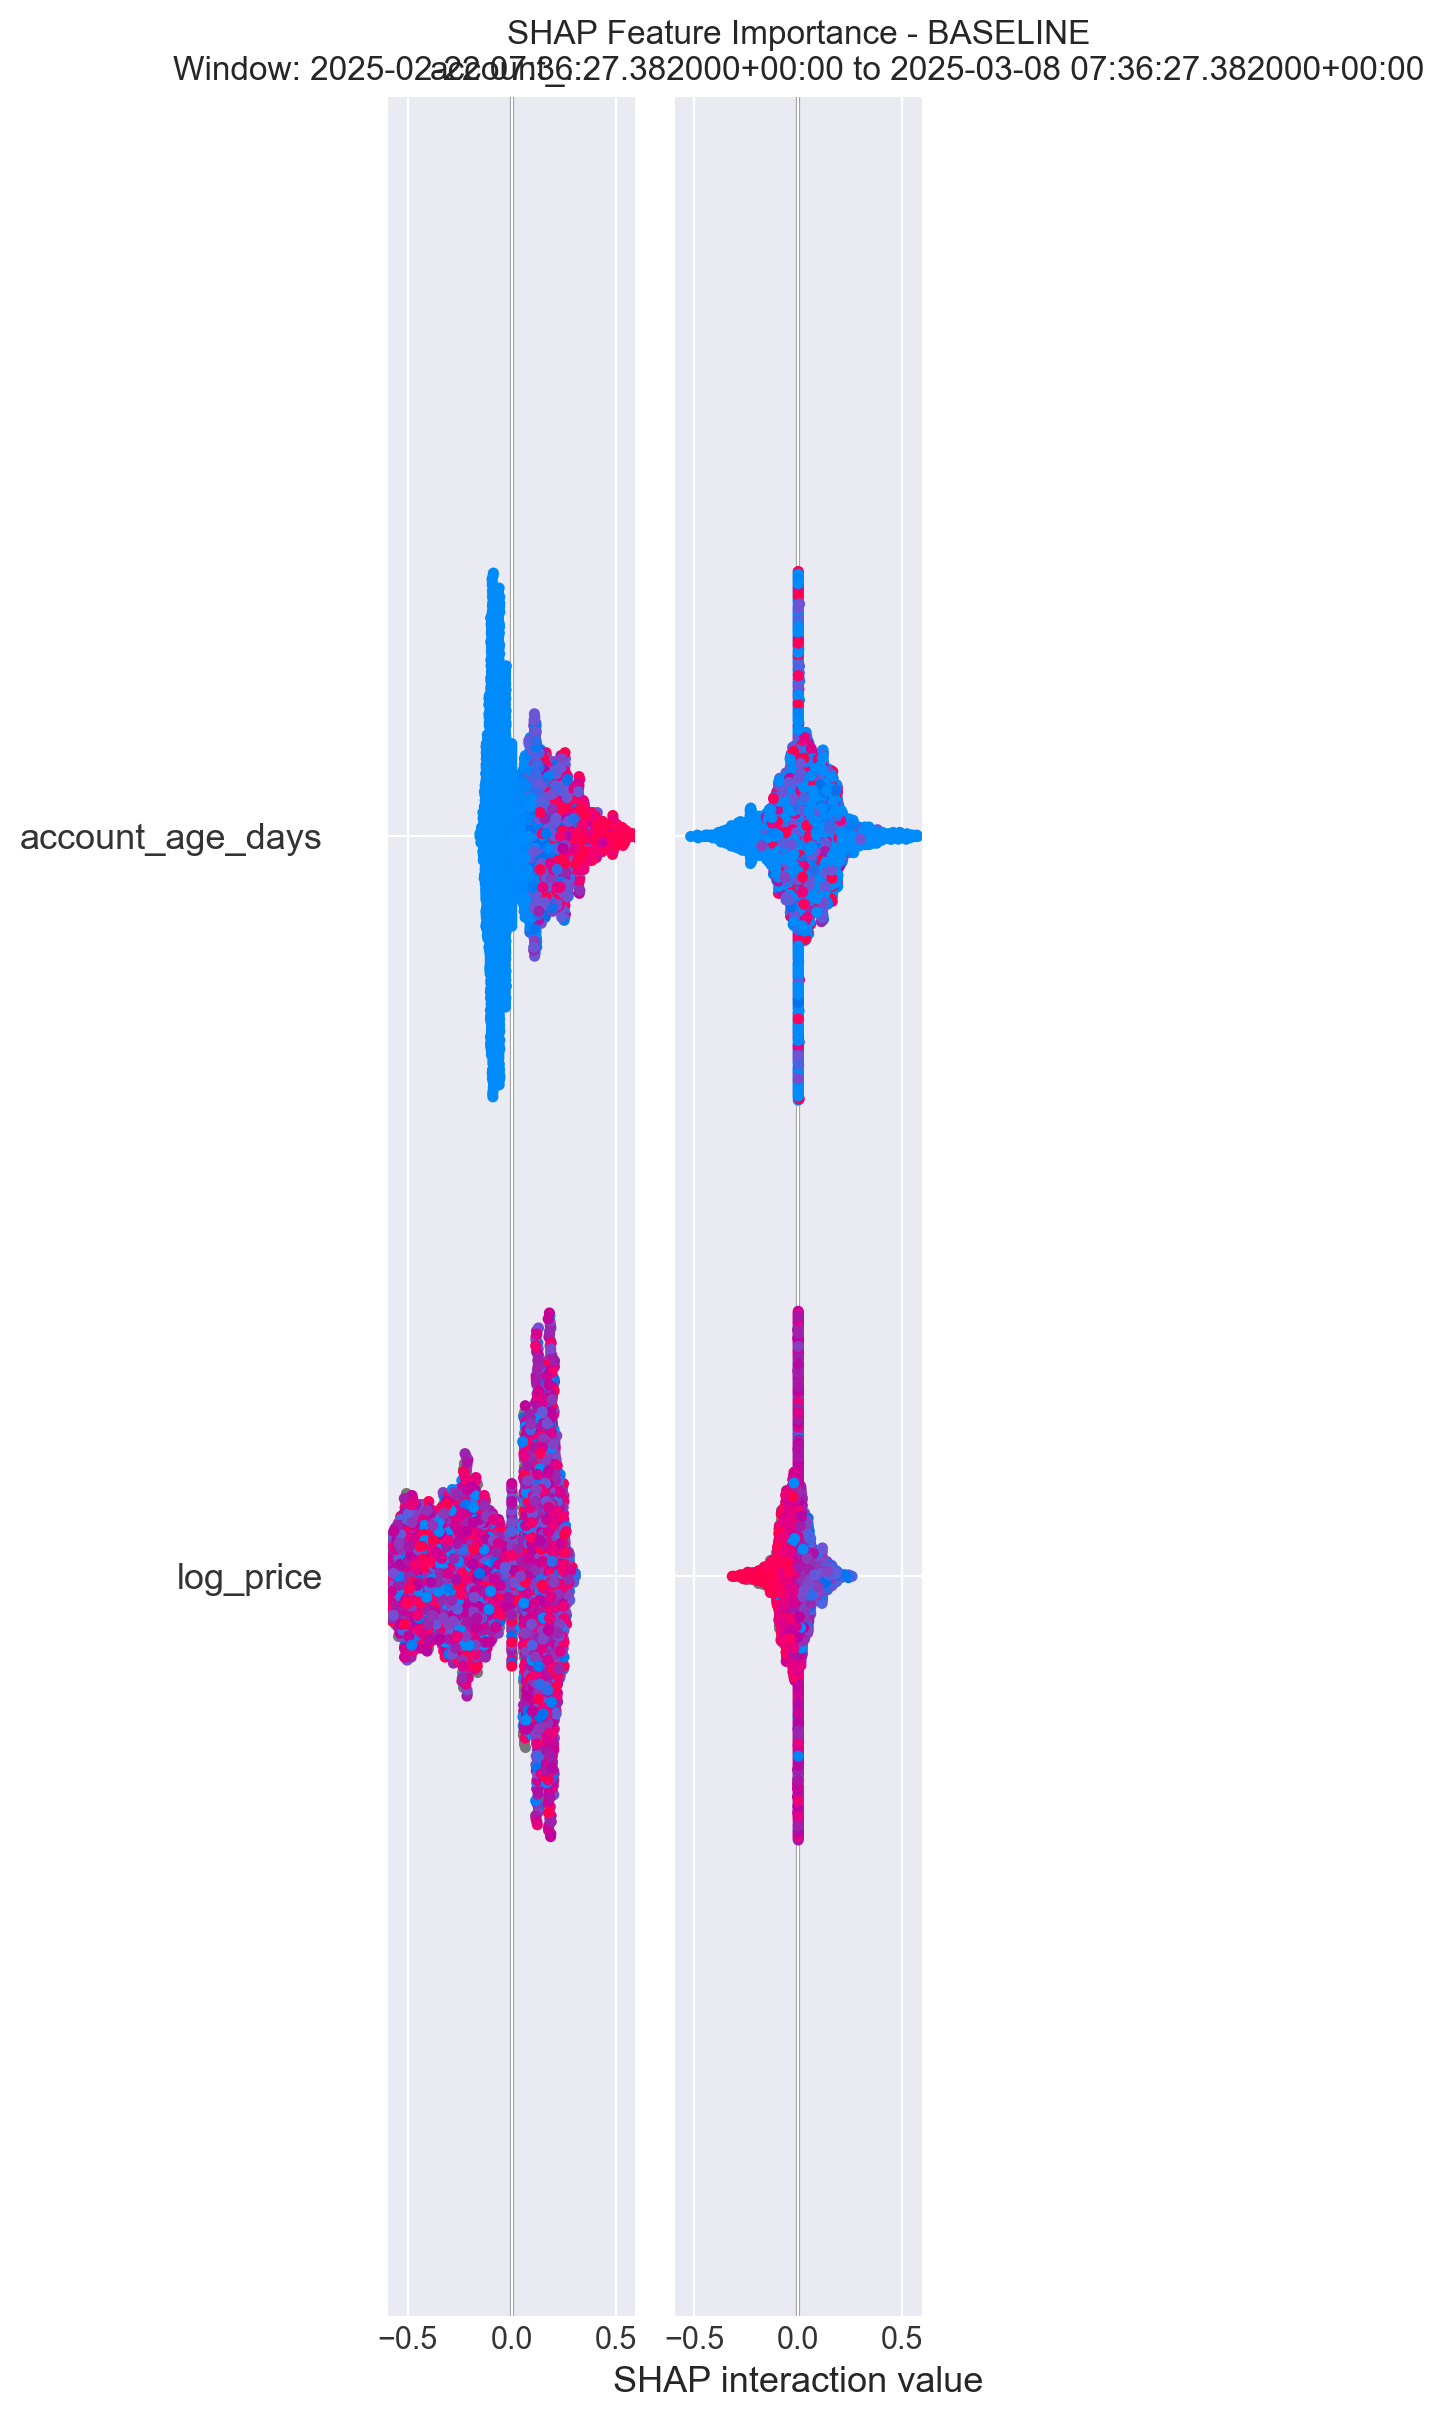

In [7]:
# Summary plot (beeswarm)
fig = explainer.plot_summary(max_display=20, aggregate_embeddings=True)
plt.show()


### 3.2 Feature Importance Bar Chart
Mean absolute SHAP values showing overall feature importance.


Generating feature importance bar chart...


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (14, 2, 2) and arg 3 with shape (14,).

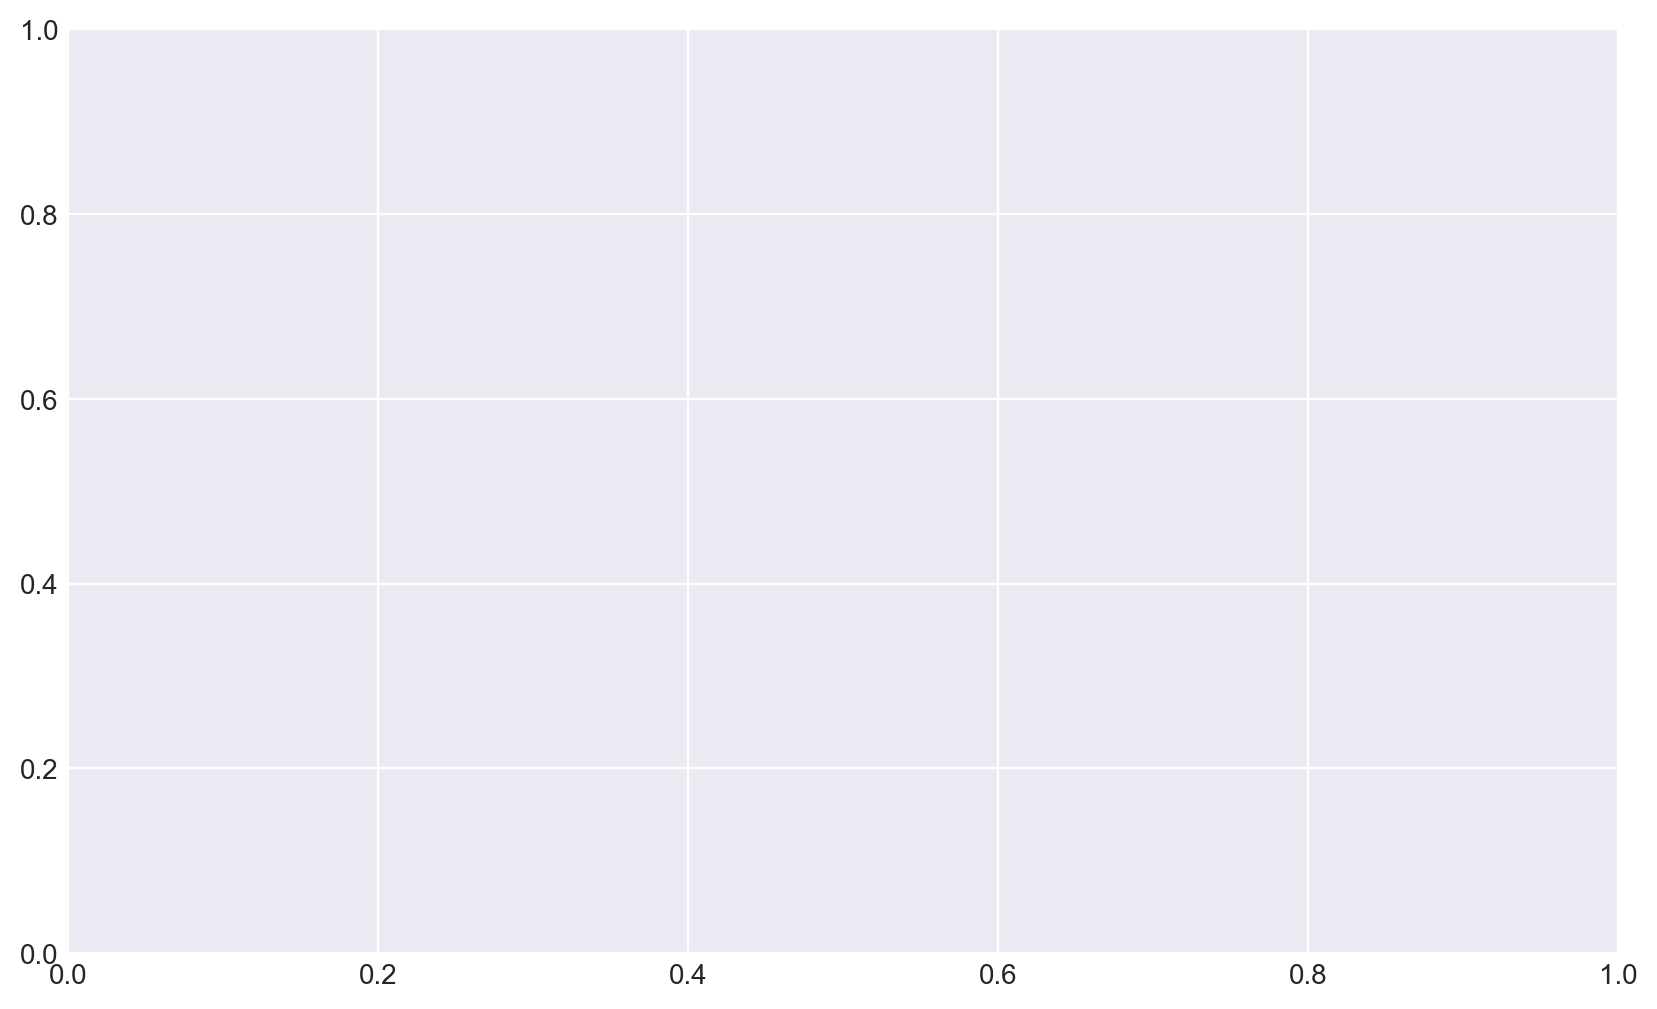

In [8]:
fig = explainer.plot_feature_importance_bar(max_display=20, aggregate_embeddings=True)
plt.show()


### 3.3 Feature Importance Table


In [ ]:
importance_df = explainer.get_feature_importance_df(aggregate_embeddings=True)
print("Top 15 Most Important Features:")
importance_df.head(15)


## 4. Feature Dependence Analysis

Understand how individual features affect predictions and their interactions.


In [ ]:
# Select top features for dependence analysis
top_features = importance_df[importance_df['feature'] != 'GNN_embeddings'].head(3)['feature'].tolist()
print(f"Analyzing dependence for: {top_features}")

for feature in top_features:
    fig = explainer.plot_dependence(feature)
    plt.show()


## 5. Local Explanations: Individual Predictions

### 5.1 Understand False Positives
Why did the model incorrectly flag legitimate listings as fraud?


In [ ]:
# Count prediction types
pred_counts = explainer.df_test['prediction_type'].value_counts()
print("Prediction Distribution:")
print(pred_counts)
print(f"\nFalse Positive Rate: {pred_counts.get('FP', 0) / (pred_counts.get('TN', 0) + pred_counts.get('FP', 0)):.2%}")
print(f"False Negative Rate: {pred_counts.get('FN', 0) / (pred_counts.get('TP', 0) + pred_counts.get('FN', 0)):.2%}")


In [ ]:
# Explain top false positives
fp_data = explainer.df_test[explainer.df_test['prediction_type'] == 'FP'].sort_values('y_pred', ascending=False)

if len(fp_data) > 0:
    print(f"Analyzing top 5 false positives out of {len(fp_data)} total")
    for i in range(min(5, len(fp_data))):
        idx = fp_data.index[i]
        print(f"\n--- False Positive {i+1} (Index: {idx}, Score: {fp_data.iloc[i]['y_pred']:.4f}) ---")
        fig = explainer.plot_waterfall(idx, aggregate_embeddings=True)
        plt.show()
else:
    print("No false positives in this window!")


### 5.2 Compare True Positives vs False Positives
What distinguishes correct fraud detections from false alarms?


In [ ]:
fig = explainer.analyze_cohort_differences('TP', 'FP', top_n_features=15)
if fig:
    plt.show()
else:
    print("Insufficient data for cohort comparison")


## 6. Model Comparison: Baseline vs Hybrid

**Key Question:** Why doesn't the hybrid model (with GNN embeddings) outperform the baseline?

Let's compare feature importance to see if embeddings are actually useful.


In [ ]:
# Load models for comparison
MODELS_TO_COMPARE = ["baseline", "hybrid_hgt"]  # Adjust based on what you've trained
COMPARISON_WINDOW_IDX = -1  # Use same window for fair comparison

explainers_dict = {}

for model_type in MODELS_TO_COMPARE:
    models_dir = project_root / "artifacts" / "models" / model_type
    
    if not models_dir.exists():
        print(f"⚠️ Models directory does not exist for {model_type}: {models_dir}")
        continue
    
    model_files = sorted(models_dir.glob("model_window_*.pkl"))
    model_files = [str(f) for f in model_files]
    
    if not model_files:
        print(f"⚠️ No models found for {model_type}. Skipping.")
        continue
    
    model_path = model_files[COMPARISON_WINDOW_IDX]
    print(f"Loading {model_type}: {os.path.basename(model_path)}")
    
    bundle = load_saved_model(model_path)
    
    exp = ModelExplainer(
        model=bundle['model'],
        feature_names=bundle['features'],
        X_test=bundle['X_test'],
        y_test=bundle['y_test'],
        y_pred=bundle['y_pred'],
        model_type=model_type,
        window_info=bundle['window_info']
    )
    
    explainers_dict[model_type] = exp
    
    print(f"  AUC-PR: {bundle['metrics']['auc_pr']:.4f}")
    print(f"  P@100: {bundle['metrics']['p@100']:.4f}")
    print(f"  Test size: {len(bundle['y_test']):,}")

print(f"\n✓ Loaded {len(explainers_dict)} models for comparison")


In [ ]:
# Generate comparison plot
if len(explainers_dict) >= 2:
    fig = compare_models(explainers_dict, top_n_features=15, aggregate_embeddings=True)
    plt.show()
else:
    print("Need at least 2 models to compare. Train additional models with --save-models flag.")


### 6.1 Embedding Contribution Analysis

For hybrid models, let's specifically examine how much the GNN embeddings contribute.


In [ ]:
# Check if we have a hybrid model loaded
hybrid_explainer = None
for name, exp in explainers_dict.items():
    if 'hybrid' in name:
        hybrid_explainer = exp
        hybrid_name = name
        break

if hybrid_explainer:
    print(f"Analyzing embedding contribution in {hybrid_name}")
    
    # Get embedding features
    embed_features = hybrid_explainer._get_embedding_features()
    print(f"\nFound {len(embed_features)} embedding features")
    
    # Calculate total embedding contribution
    embed_indices = [i for i, name in enumerate(hybrid_explainer.feature_names) if name in embed_features]
    embed_shap = hybrid_explainer.shap_values[:, embed_indices]
    
    # Total embedding SHAP per instance
    total_embed_shap = np.sum(embed_shap, axis=1)
    
    # Statistics
    print(f"\nEmbedding Contribution Statistics:")
    print(f"  Mean absolute embedding SHAP: {np.abs(embed_shap).mean():.6f}")
    print(f"  Mean absolute total SHAP: {np.abs(hybrid_explainer.shap_values).mean():.6f}")
    print(f"  Embedding contribution: {np.abs(embed_shap).mean() / np.abs(hybrid_explainer.shap_values).mean() * 100:.2f}%")
    
    # Distribution plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(np.abs(total_embed_shap), bins=50, alpha=0.7, label='Absolute Embedding SHAP')
    ax.set_xlabel('|Total Embedding SHAP|')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Embedding Contribution Across Test Set')
    ax.legend()
    plt.show()
else:
    print("No hybrid model found. Train a hybrid model with: python -m src.cli train-hybrid --save-models")


## 7. Export Results

Save all visualizations and feature importance tables for reporting.


In [ ]:
# Export all SHAP visualizations for the current model
if 'explainer' in locals() and 'model_bundle' in locals():
    window_idx = model_bundle['window_info'].get('window_idx', 'unknown')
    output_dir = project_root / "artifacts" / "shap" / MODEL_TYPE / f"window_{window_idx}"
    
    print(f"Saving all SHAP visualizations to {output_dir}...")
    save_explainer(explainer, str(output_dir), prefix="")
    print("✓ Export complete!")
else:
    print("No explainer loaded. Run the cells above first.")


## Next Steps

1. **Compare multiple windows**: Run this analysis across different time windows to see if feature importance is stable
2. **Deep dive on embeddings**: If embeddings are weak, investigate:
   - Graph structure quality (sparsity, connectivity)
   - GNN architecture (try different models: GAT, SAGE, HGT)
   - Embedding dimensionality (try 64, 128, 256)
3. **Feature engineering**: Based on top features, create interactions or derived features
4. **Threshold tuning**: Use SHAP insights to set better classification thresholds
